<a href="https://colab.research.google.com/github/Alexd17d/SIAV/blob/main/Redise%C3%B1o_de_los_KPIs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Conectando con Google Drive...
Mounted at /content/drive
Paquete 'TPS.zip' detectado en tu Drive. Procesando base de datos...
Carga transaccional real completada desde Drive.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

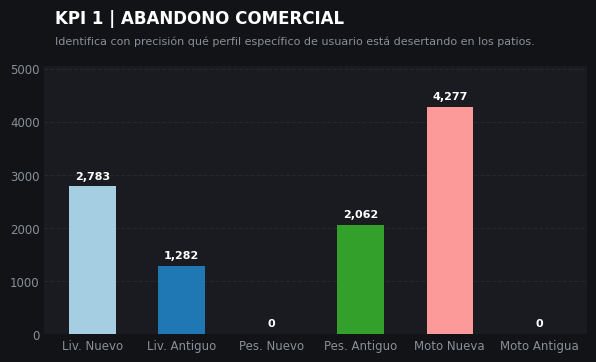

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

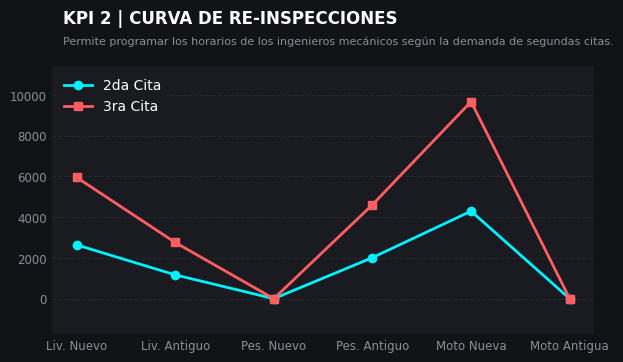

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

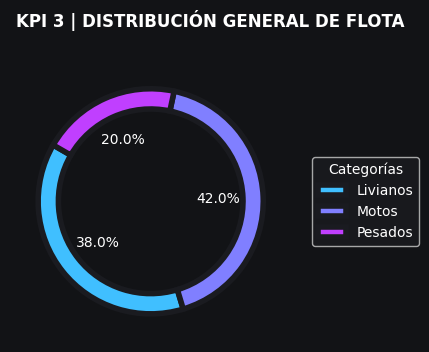

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

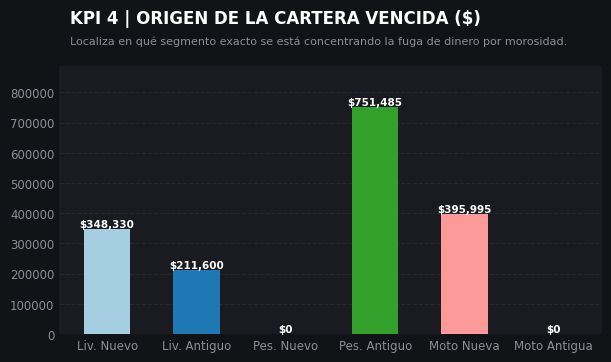

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

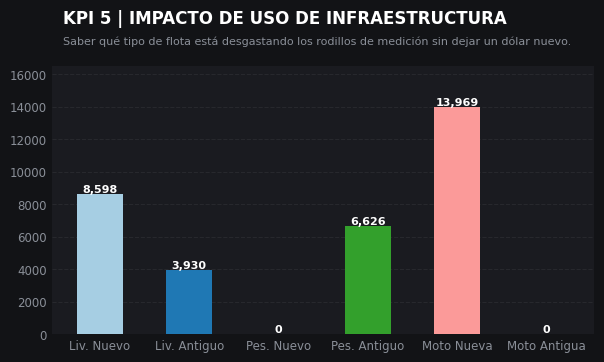

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

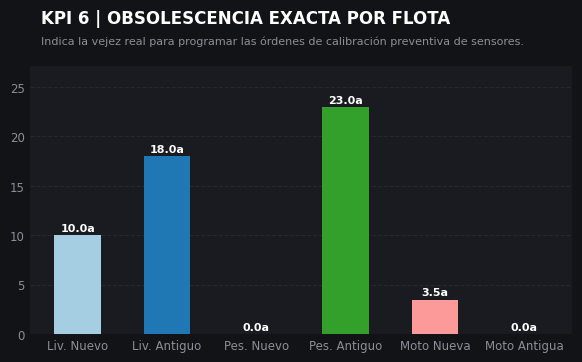

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

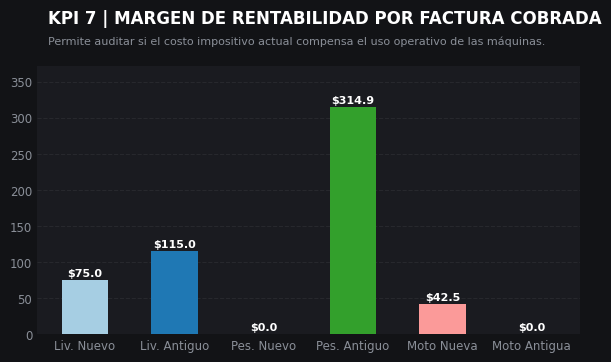

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

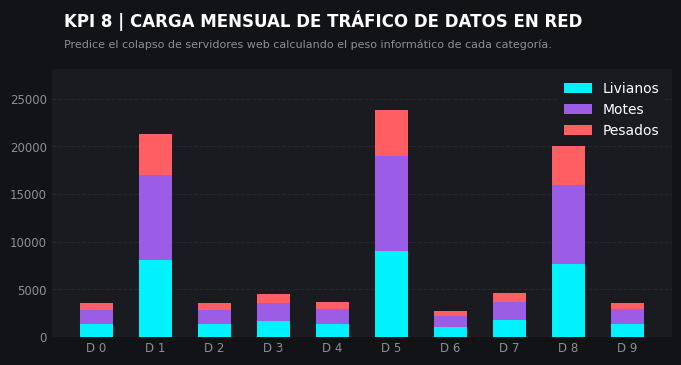

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Librería core de Ciencia de Datos para manipulación vectorial mediante DataFrames
import pandas as pd
# Componentes nativos de Google Colab para renderizar la interfaz de pestañas
from google.colab import widgets
from google.colab import drive
import zipfile
import os

print(" Conectando con Google Drive...")
drive.mount('/content/drive')

ruta_zip_drive = "/content/drive/MyDrive/Colab Notebooks/TPS.zip"
os.makedirs("data", exist_ok=True)

# Validación de existencia del paquete transaccional comprimido
if os.path.exists(ruta_zip_drive):
    print(f"Paquete 'TPS.zip' detectado en tu Drive. Procesando base de datos...")
    with zipfile.ZipFile(ruta_zip_drive, 'r') as zip_ref:
        zip_ref.extractall(".") # Extrae el árbol de archivos en el directorio raíz de Colab
    print("Carga transaccional real completada desde Drive.\n")
else:
    # Lanza una excepción controlada si el archivo no se encuentra en la ruta parametrizada
    raise FileNotFoundError(f"No se encontró el archivo en la ruta: {ruta_zip_drive}")

# Enrutamiento dinámico para localizar el archivo plano de transacciones
ruta_vehiculos = "TPS/data/vehiculos.txt"
if not os.path.exists(ruta_vehiculos):
    ruta_vehiculos = "data/vehiculos.txt"


# 2. CARGA Y PREPROCESAMIENTO CON PANDAS

# Mapeo y definición manual de las columnas debido a la ausencia de cabecera  en el TXT
columnas = ['id_transaccion', 'placa', 'col2', 'anio', 'tipo', 'col5', 'r1', 'r2', 'r3']

# Ingesta automatizada: Transforma el archivo plano directamente en una estructura estructurada en bloque
df = pd.read_csv(ruta_vehiculos, sep=",", names=columnas, engine='python')

# Recupera el volumen total de filas (registros) mediante la función matemática len()
total_vehiculos = len(df)

# Operación lógica vectorial: Asigna 'True' si el auto registra un bit '1' en r1, r2 O r3 (Aprobado)
df['es_matriculado'] = (df['r1'] == 1) | (df['r2'] == 1) | (df['r3'] == 1)

# Deducción de la antigüedad restando el año de auditoría directiva (2026) menos el año del modelo
df['antiguedad_anios'] = 2026 - df['anio']

# Segmentación de edad ejecutiva usando una función lambda (Umbral límite: 15 años)
df['edad_segmento'] = df['antiguedad_anios'].apply(lambda x: 'nuevo' if x <= 15 else 'antiguo')

# Concatenación de strings vectoriales para estructurar la clave única tridimensional de categoría
df['cat_clave'] = df['tipo'] + "_" + df['edad_segmento']

# Extracción posicional del último carácter de la placa con manejo de nulos y casteo forzado a entero
df['ultimo_digito'] = df['placa'].str[-1].fillna('0').apply(lambda x: int(x) if x.isdigit() else 0)

# Asignación de Tasa Base condicional: Camiones pesados tributan $200.00; ligeros y motos $25.00
df['tasa_base'] = df['tipo'].apply(lambda x: 200.0 if x == 'pesado' else 25.0)

# Ecuación impositiva: Tasa Base + ($5 * años de vejez) + ($50 de recargo de multa si es_matriculado es False)
df['valor_matricula'] = df['tasa_base'] + (df['antiguedad_anios'] * 5.0) + df['es_matriculado'].apply(lambda x: 0.0 if x else 50.0)

# REDUCCIÓN DE DATOS PARA PESTAÑA 0
# Cuenta las filas totales donde la condición booleana de matriculación es Falsa (~ invierte el operador)
sin_revision = len(df[~df['es_matriculado']])

# Conteo directo de aprobaciones concurrentes filtrando por la bandera de andén evaluada en 1
aprobado_2da = len(df[df['r2'] == 1])
aprobado_3ra = len(df[df['r3'] == 1])
total_reinspecciones = aprobado_2da + aprobado_3ra # Trabajo doble que satura andenes de la planta

# Filtros booleanos instantáneos para cuantificar el volumen por tipología física de transporte
conteo_livianos = len(df[df['tipo'] == 'liviano'])
conteo_pesados = len(df[df['tipo'] == 'pesado'])
conteo_motos = len(df[df['tipo'] == 'moto'])

# Reducción por agregación sumatoria de la columna 'valor_matricula' para balances netos
recaudacion_proyectada_total = df['valor_matricula'].sum() # Caja ideal esperada
recaudacion_real = df[df['es_matriculado']]['valor_matricula'].sum() # Caja real efectiva en banco

# Operación de sustracción directa para hallar el residuo económico evadido
fuga_dinero = recaudacion_proyectada_total - recaudacion_real
# Proporción porcentual clásica del índice de deserción comercial
tasa_churn = (sin_revision / total_vehiculos) * 100


# 3. PARÁMETROS ESTÉTICOS

HEX_BG, HEX_CARD, HEX_TEXT, HEX_MUTED = '#121316', '#1a1b20', '#ffffff', '#8a8f98'
PALETA_COMPLETA = sns.color_palette("Paired", 6)
EJE_X_LABELS = ['Liv. Nuevo', 'Liv. Antiguo', 'Pes. Nuevo', 'Pes. Antiguo', 'Moto Nueva', 'Moto Antigua']
ORDEN_CATEGORIAS = ['liviano_nuevo', 'liviano_antiguo', 'pesado_nuevo', 'pesado_antiguo', 'moto_nuevo', 'moto_antiguo']

plt.style.use('dark_background')

def estilizar_tarjeta_ui(ax, titulo_kpi, subtitulo):
    """
    Función modular para estandarizar el look and feel corporativo de Matplotlib.
    Elimina ruidos visuales, bordes (spines) e inyecta la paleta Dark de SIAV.
    """
    ax.set_facecolor(HEX_CARD) # Fondo interno de la tarjeta
    fig = ax.get_figure()
    fig.patch.set_facecolor(HEX_BG) # Fondo externo de la app
    # Inyección de títulos con coordenadas absolutas de control de ejes
    ax.text(0.02, 1.16, titulo_kpi, transform=ax.transAxes, fontsize=12, fontweight='bold', color=HEX_TEXT)
    ax.text(0.02, 1.08, subtitulo, transform=ax.transAxes, fontsize=8, color=HEX_MUTED)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False) # Apaga las 4 líneas de contorno
    ax.tick_params(colors=HEX_MUTED, labelsize=8.5, length=0)
    ax.yaxis.grid(True, linestyle='--', alpha=0.06, color=HEX_TEXT) # Cuadrícula sutil de referencia
    ax.set_axisbelow(True) # Fuerza a la grilla a mantenerse detrás de los gráficos
    ax.margins(y=0.18) # Holgura superior del 18% para evitar cortes de texto


# 4. DESPLIEGUE POR PESTAÑAS INTERACTIVAS

tb = widgets.TabBar(['Dashboard', 'KPI 1', 'KPI 2', 'KPI 3', 'KPI 4', 'KPI 5', 'KPI 6', 'KPI 7', 'KPI 8'])

# --- PESTAÑA 0: DASHBOARD PRINCIPAL ---
with tb.output_to(0):
    print("="*75)
    print("   CONTROL DE MARGEN Y RENTABILIDAD INTERNA ")
    print("="*75)
    print(f"   REGISTROS TOTALES     :  {total_vehiculos:,} vehículos procesados")
    print(f"   CLIENTES QUE SE VAN   :  {tasa_churn:.2f}% de abandono comercial")
    print("-"*75)
    print(f"    ÁREA               INDICADOR CRÍTICO                  VALOR")
    print("   ───────────────────────────────────────────────────────────────────────────")
    print(f"    DINERO REAL         Dinero que ya entró al banco       ${recaudacion_real:,.2f}")
    print(f"    DINERO PERDIDO      Cuentas que no se cobraron         ${fuga_dinero:,.2f}")
    print(f"    TRABAJO DOBLE       Citas repetidas por fallas         {total_reinspecciones:,} revisiones")
    print(f"    Flota Dominante     Categoría con mayor volumen        {conteo_motos:,} motos")
    print("   ───────────────────────────────────────────────────────────────────────────")
    print("="*75)

# --- PESTAÑA 1: KPI 1 (Abandono Comercial por Subcategoría) ---
with tb.output_to(1):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)

    # PANDAS GROUPBY: Filtra desertores, agrupa por clave y extrae las frecuencias agregadas de forma instantánea
    df_churn = df[~df['es_matriculado']].groupby('cat_clave').size().reindex(ORDEN_CATEGORIAS, fill_value=0)

    barras = ax.bar(EJE_X_LABELS, df_churn.values, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (sin_revision*0.01), f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=8, fontweight='bold', color=HEX_TEXT)
    estilizar_tarjeta_ui(ax, "KPI 1 | ABANDONO COMERCIAL", "Identifica con precisión qué perfil específico de usuario está desertando en los patios.")
    plt.show()

# --- PESTAÑA 2: KPI 2 (Curva de Re-inspecciones Segmentadas) ---
with tb.output_to(2):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)

    # SEGMENTACIÓN AVANZADA PANDAS: Agrupa de manera independiente los volúmenes usando la máscara condicional del andén
    df_c2 = df[df['r2'] == 1].groupby('cat_clave').size().reindex(ORDEN_CATEGORIAS, fill_value=0)
    df_c3 = df[df['r3'] == 1].groupby('cat_clave').size().reindex(ORDEN_CATEGORIAS, fill_value=0)

    # Superposición de vectores sobre el mismo objeto 'ax' para contrastar las curvas dinámicas
    ax.plot(EJE_X_LABELS, df_c2.values, marker='o', label='2da Cita', color='#00f2fe', linewidth=2)
    ax.plot(EJE_X_LABELS, df_c3.values, marker='s', label='3ra Cita', color='#ff5e62', linewidth=2)
    ax.legend(facecolor=HEX_CARD, edgecolor='none', labelcolor=HEX_TEXT)
    estilizar_tarjeta_ui(ax, "KPI 2 | CURVA DE RE-INSPECCIONES", "Permite programar los horarios de los ingenieros mecánicos según la demanda de segundas citas.")
    plt.show()

# --- PESTAÑA 3: KPI 3 (Distribución General de la Flota) ---
with tb.output_to(3):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    plt.subplots_adjust(top=0.78, right=0.65)

    # Renderizado del gráfico de anillo mediante la inyección directa de las variables de conteo agregadas
    wedges, texts, autotexts = ax.pie([conteo_livianos, conteo_motos, conteo_pesados], labels=None, autopct='%1.1f%%', startangle=150, colors=sns.color_palette("cool", 3), wedgeprops=dict(width=0.18, edgecolor=HEX_CARD, linewidth=4))
    fig.patch.set_facecolor(HEX_BG)
    ax.set_facecolor(HEX_CARD)
    ax.text(0.02, 1.12, "KPI 3 | DISTRIBUCIÓN GENERAL DE FLOTA", transform=ax.transAxes, fontsize=12, fontweight='bold', color=HEX_TEXT)
    ax.legend(wedges, ['Livianos', 'Motos', 'Pesados'], title="Categorías", loc="center left", bbox_to_anchor=(1.05, 0.5), facecolor=HEX_CARD, labelcolor=HEX_TEXT)
    plt.show()

# --- PESTAÑA 4: KPI 4 (Origen de la Cartera Vencida) ---
with tb.output_to(4):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)

    # OPERACIÓN MÁSCARA EN PANDAS: Filtra los evasores y aplica el método .sum() de forma exclusiva a la columna monetaria
    df_fuga = df[~df['es_matriculado']].groupby('cat_clave')['valor_matricula'].sum().reindex(ORDEN_CATEGORIAS, fill_value=0)

    barras = ax.bar(EJE_X_LABELS, df_fuga.values, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"${bar.get_height():,.0f}", ha='center', va='bottom', fontweight='bold', color=HEX_TEXT, fontsize=7.5)
    estilizar_tarjeta_ui(ax, "KPI 4 | ORIGEN DE LA CARTERA VENCIDA ($)", "Localiza en qué segmento exacto se está concentrando la fuga de dinero por morosidad.")
    plt.show()

# --- PESTAÑA 5: KPI 5 (Impacto de Uso de Infraestructura Física) ---
with tb.output_to(5):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)

    # Filtro de reincidentes combinando operadores OR (|) a nivel bitwise en el DataFrame
    df_rep = df[(df['r2'] == 1) | (df['r3'] == 1)].groupby('cat_clave').size().reindex(ORDEN_CATEGORIAS, fill_value=0)

    barras = ax.bar(EJE_X_LABELS, df_rep.values, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f"{int(bar.get_height()):,}", ha='center', va='bottom', fontweight='bold', color=HEX_TEXT, fontsize=8)
    estilizar_tarjeta_ui(ax, "KPI 5 | IMPACTO DE USO DE INFRAESTRUCTURA", "Saber qué tipo de flota está desgastando los rodillos de medición sin dejar un dólar nuevo.")
    plt.show()

# --- PESTAÑA 6: KPI 6 (Obsolescencia Exacta por Flota) ---
with tb.output_to(6):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)

    # VECTORIAL MEAN: Saca el promedio aritmético exacto de antigüedad por grupo omitiendo divisiones manuales para cero
    df_edad = df.groupby('cat_clave')['antiguedad_anios'].mean().reindex(ORDEN_CATEGORIAS, fill_value=0)

    barras = ax.bar(EJE_X_LABELS, df_edad.values, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{bar.get_height():.1f}a", ha='center', va='bottom', fontweight='bold', color=HEX_TEXT, fontsize=8)
    estilizar_tarjeta_ui(ax, "KPI 6 | OBSOLESCENCIA EXACTA POR FLOTA", "Indica la vejez real para programar las órdenes de calibración preventiva de sensores.")
    plt.show()

# --- PESTAÑA 7: KPI 7 (Margen de Rentabilidad por Factura Cobrada) ---
with tb.output_to(7):
    fig, ax = plt.subplots(figsize=(7, 4))
    plt.subplots_adjust(top=0.78)

    # Saca el ticket promedio filtrando de golpe las unidades que sí registran éxito financiero en el banco
    df_ticket = df[df['es_matriculado']].groupby('cat_clave')['valor_matricula'].mean().reindex(ORDEN_CATEGORIAS, fill_value=0)

    barras = ax.bar(EJE_X_LABELS, df_ticket.values, color=PALETA_COMPLETA, width=0.52)
    for bar in barras:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"${bar.get_height():,.1f}", ha='center', va='bottom', fontweight='bold', color=HEX_TEXT, fontsize=8)
    estilizar_tarjeta_ui(ax, "KPI 7 | MARGEN DE RENTABILIDAD POR FACTURA COBRADA", "Permite auditar si el costo impositivo actual compensa el uso operativo de las máquinas.")
    plt.show()

# --- PESTAÑA 8: KPI 8 (Carga Mensual de Tráfico de Datos en Red) ---
with tb.output_to(8):
    fig, ax = plt.subplots(figsize=(8, 4))
    plt.subplots_adjust(top=0.78)

    # PANDAS PIVOT TABLE: Genera de manera nativa la matriz cruzada bidimensional de Placas vs Tipo Físico
    pivot = df.pivot_table(index='ultimo_digito', columns='tipo', aggfunc='size', fill_value=0)
    digitos = [f"D {i}" for i in range(10)]

    # Recuperación indexada por vector numérico de los tres perfiles del parque automotor
    livi_p = pivot['liviano'].reindex(range(10), fill_value=0).values
    moto_p = pivot['moto'].reindex(range(10), fill_value=0).values
    pesa_p = pivot['pesado'].reindex(range(10), fill_value=0).values

    # ESTRUCTURA DE APILAMIENTO VECTORIAL (Stacked Bar Chart usando sumas directas de Series)
    b1 = ax.bar(digitos, livi_p, label='Livianos', color='#00f2fe', width=0.55)
    b2 = ax.bar(digitos, moto_p, bottom=livi_p, label='Motes', color='#9b5de5', width=0.55) # Apila motos usando de suelo a livianos
    b3 = ax.bar(digitos, pesa_p, bottom=livi_p + moto_p, label='Pesados', color='#ff5e62', width=0.55) # Suelo = suma vectorial acumulada

    ax.legend(facecolor=HEX_CARD, edgecolor='none', labelcolor=HEX_TEXT)
    estilizar_tarjeta_ui(ax, "KPI 8 | CARGA MENSUAL DE TRÁFICO DE DATOS EN RED", "Predice el colapso de servidores web calculando el peso informático de cada categoría.")
    plt.show()